In [ ]:
import kagglehub
prekshapalva_indian_sign_language_path = kagglehub.dataset_download('prekshapalva/indian-sign-language')
drblack00_isl_csltr_indian_sign_language_dataset_path = kagglehub.dataset_download('drblack00/isl-csltr-indian-sign-language-dataset')

print('Data source import complete.')


Data source import complete.


In [ ]:

# 📦 Imports
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from torch.utils.data import random_split

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on {device}')


Training on cuda


In [ ]:
#  Paths & Hyperparameters
# Use the path from kagglehub.dataset_download
data_dir = os.path.join(prekshapalva_indian_sign_language_path, 'Dataset')
batch_size = 30
lr = 0.001
epochs =10
img_size = 128

# 📈 Transforms
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [ ]:
#  Full Dataset
# Use the path from kagglehub.dataset_download
data_dir = os.path.join(prekshapalva_indian_sign_language_path, 'Dataset')
full_dataset = datasets.ImageFolder(data_dir, transform=transform)

#  Class Info
class_names = full_dataset.classes
num_classes = len(class_names)

#  Train/Val/Test Split
train_size = int(0.7 * len(full_dataset)) # Adjusted to 70% for training
val_size = int(0.15 * len(full_dataset)) # 15% for validation
test_size = len(full_dataset) - train_size - val_size # Remaining for testing
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class ISLCNN(nn.Module):
    def __init__(self, num_classes):
        super(ISLCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 64x64 -> 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32x32 -> 16x16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16x16 -> 8x8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)   # 8x8 -> 4x4
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))  # 4x4 -> 1x1 per channel
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)  # flatten all except batch dimension
        x = self.fc(x)
        return x

model = ISLCNN(num_classes=num_classes).to(device)
print(model)

ISLCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affin

In [ ]:

# ⚙️ Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


Epoch 1/10 | Train Loss: 0.590 | Train Accuracy: 81.83% | Val Loss: 1.872 | Val Accuracy: 61.20%
Epoch 2/10 | Train Loss: 0.078 | Train Accuracy: 97.72% | Val Loss: 0.050 | Val Accuracy: 97.98%
Epoch 3/10 | Train Loss: 0.050 | Train Accuracy: 98.49% | Val Loss: 0.049 | Val Accuracy: 98.21%
Epoch 4/10 | Train Loss: 0.042 | Train Accuracy: 98.76% | Val Loss: 0.013 | Val Accuracy: 99.58%
Epoch 5/10 | Train Loss: 0.031 | Train Accuracy: 99.11% | Val Loss: 0.014 | Val Accuracy: 99.56%
Epoch 6/10 | Train Loss: 0.029 | Train Accuracy: 99.11% | Val Loss: 0.007 | Val Accuracy: 99.76%
Epoch 7/10 | Train Loss: 0.024 | Train Accuracy: 99.26% | Val Loss: 0.004 | Val Accuracy: 99.88%
Epoch 8/10 | Train Loss: 0.021 | Train Accuracy: 99.40% | Val Loss: 0.006 | Val Accuracy: 99.75%
Epoch 9/10 | Train Loss: 0.018 | Train Accuracy: 99.40% | Val Loss: 0.006 | Val Accuracy: 99.83%
Epoch 10/10 | Train Loss: 0.016 | Train Accuracy: 99.53% | Val Loss: 0.002 | Val Accuracy: 99.95%


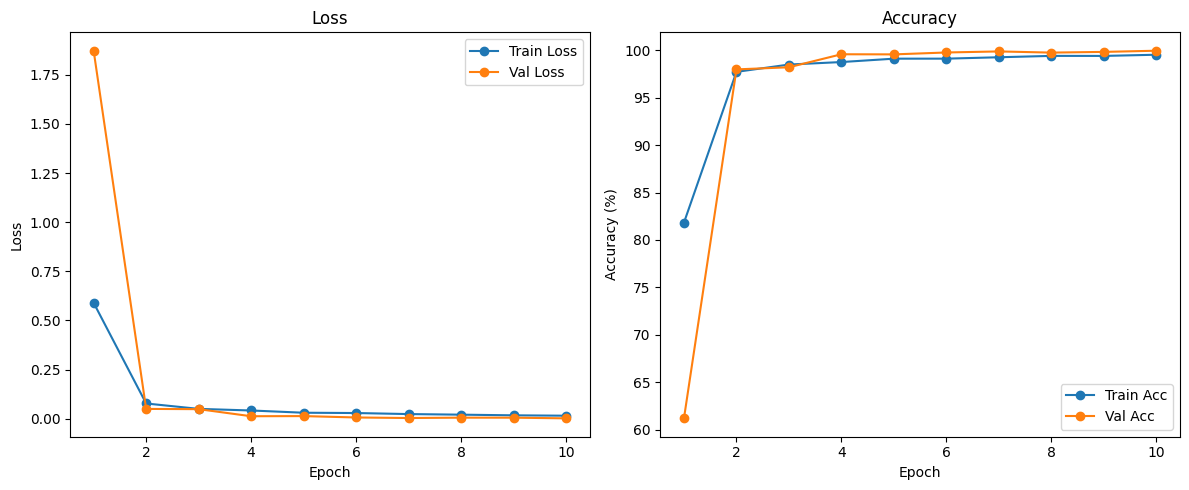

Final Training Accuracy: 99.53%
Final Validation Accuracy: 99.95%


In [ ]:
# Initialize lists to store loss and accuracy for plotting
running_losses = []
acc = []
val_losses = []
val_acc = []

# 🔁 Training Loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    # Calculate average training loss and accuracy for the epoch
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total

    running_losses.append(epoch_train_loss)
    acc.append(epoch_train_acc)

    # Evaluation on validation set
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    # Calculate average validation loss and accuracy for the epoch
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total

    val_losses.append(epoch_val_loss)
    val_acc.append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.3f} | Train Accuracy: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.3f} | Val Accuracy: {epoch_val_acc:.2f}%")

# Plot loss and accuracy
epochs_range = range(1, epochs + 1) # Use the 'epochs' variable from previous cells
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, running_losses, 'o-', label="Train Loss") # Use running_losses list
plt.plot(epochs_range, val_losses, 'o-', label="Val Loss") # Use val_losses list
plt.xlabel("Epoch"), plt.ylabel("Loss"), plt.title("Loss"), plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, 'o-', label="Train Acc") # Use acc list
plt.plot(epochs_range, val_acc, 'o-', label="Val Acc") # Use val_acc list
plt.xlabel("Epoch"), plt.ylabel("Accuracy (%)"), plt.title("Accuracy"), plt.legend()
plt.tight_layout()
plt.show()

# Print final accuracies
print(f"Final Training Accuracy: {acc[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1]:.2f}%")

## Evaluate on Test Set

Now that the model has been trained and validated, let's evaluate its performance on the test dataset.

In [ ]:
#  Evaluation Loop on Test Set
model.eval()
test_loss = 0.0
correct, total = 0, 0

# Lists to store true and predicted labels for precision and F1 calculation
y_true = []
y_pred = []


with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        y_true.extend(labels.cpu().numpy()) # Collect true labels
        y_pred.extend(predicted.cpu().numpy()) # Collect predicted labels


test_accuracy = 100 * correct / total
print(f"\n📊 Test Loss: {test_loss:.3f} | Test Accuracy: {test_accuracy:.2f}%")


📊 Test Loss: 0.192 | Test Accuracy: 99.99%


## Calculate Metrics and Confusion Matrix

Let's calculate precision, F1-score, and visualize the confusion matrix to get a more detailed understanding of the model's performance.

🎯 Precision (weighted): 1.000
🎯 F1 Score (weighted): 1.000


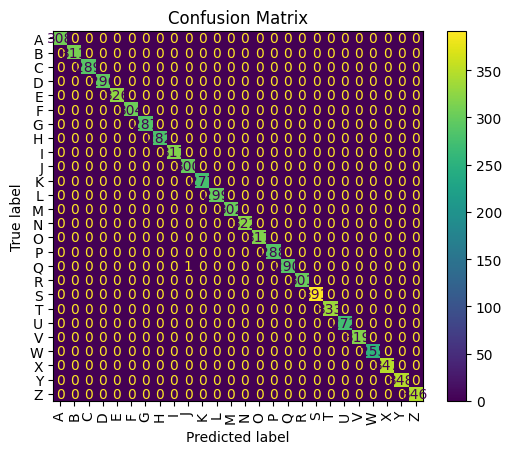

In [ ]:
from sklearn.metrics import precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate Precision and F1 Score
# Use 'weighted' average to account for class imbalance, if any
precision = precision_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f" Precision (weighted): {precision:.3f}")
print(f" F1 Score (weighted): {f1:.3f}")


# Optional: Confusion Matrix (For Deeper Analysis)
#  Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()

## Save Model

Let's save the trained model's state dictionary so it can be loaded and used later for inference.

In [ ]:
# 💾 Save Model
torch.save(model.state_dict(), 'isl_cnn_model.pth')

In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import os

# Load the trained model
# Assuming model and num_classes are defined in previous cells
# model = ISLCNN(num_classes).to(device)
model.load_state_dict(torch.load('isl_cnn_model.pth'))
model.eval()

# Define the same transformations used during training
# Assuming img_size is defined in a previous cell
# img_size = 128
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# --- Replace 'path/to/your/image.jpg' with the actual path to an image file ---


image_path = "/Image_1679047254.4765236.jpg"


 # **UPDATE THIS PATH** - Corrected typo

if not os.path.exists(image_path):
    print(f"Error: Image not found at {image_path}")
else:
    # Load and preprocess the image
    image = Image.open(image_path).convert('RGB') # Ensure image is in RGB
    image = transform(image).unsqueeze(0).to(device) # Add batch dimension and move to device

    # Predict the gesture
    with torch.no_grad():
        outputs = model(image)
        _, predicted_index = torch.max(outputs, 1)
        # Assuming class_names is defined in a previous cell
        predicted_gesture = class_names[predicted_index.item()]

    print(f"The predicted gesture is: {predicted_gesture}")

The predicted gesture is: S
